# CSRLE — Controlled Synthetic Residual Learnability Experiment

**Read-only visualization notebook** (no training, no artifact overwrites).

Mirrors the structure of `hybrid_model.ipynb`: configuration → data → summary tables → matrices → exploratory plots → representative-container demo.

| Phase | Content |
|-------|---------|
| Pre-GRU | Synthetic data, α distribution, Prophet retention |
| Stage 1 | Condition A (real-data) Hybrid reproduction |
| Stage 2 | B0 / B1 / C0 / C1 independent GRU evaluation |

**Authoritative experiment:** `experiments/synthetic_residual_learnability_2026-07-25_164307/`

Execute cells sequentially. Most sections load precomputed CSV/JSON (fast). Optional Section 10 runs single-container inference.


## 1 — Configuration


In [1]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import pandas as pd

REPO_ROOT = Path('..').resolve()
CSRLE_EXP = REPO_ROOT / 'experiments' / 'synthetic_residual_learnability_2026-07-25_164307'
STAGE1 = CSRLE_EXP / 'stage1_control_reproduction'
STAGE2 = CSRLE_EXP / 'stage2_synthetic_gru'
PREGRU = CSRLE_EXP / 'synthetic_validation'
DATA = CSRLE_EXP / 'data'

# Optional: save figures from notebook (new folder — does not overwrite Stage 1/2)
SAVE_FIGS = False
FIG_DIR = CSRLE_EXP / 'notebook_visualizations'
if SAVE_FIGS:
    FIG_DIR.mkdir(parents=True, exist_ok=True)

CONDITIONS = {
    'A (control)': ('control', STAGE1),
    'B0': ('b0_lc', STAGE2 / 'b0_lc'),
    'B1': ('b1_snar', STAGE2 / 'b1_snar'),
    'C0': ('c0_iid', STAGE2 / 'c0_iid'),
    'C1': ('c1_iid', STAGE2 / 'c1_iid'),
}
STAGE2_SYN = ['b0_lc', 'b1_snar', 'c0_iid', 'c1_iid']

plt.rcParams.update({'figure.figsize': (10, 4), 'font.size': 11})


def plot_heatmap(matrix: pd.DataFrame, title: str, center: float = 0.0) -> None:
    """Matplotlib heatmap (no seaborn dependency)."""
    data = matrix.values.astype(float)
    vmax = max(abs(data.min() - center), abs(data.max() - center), 1e-6)
    norm = TwoSlopeNorm(vmin=center - vmax, vcenter=center, vmax=center + vmax)
    fig, ax = plt.subplots(figsize=(8, 4))
    im = ax.imshow(data, aspect='auto', cmap='RdYlGn', norm=norm)
    ax.set_xticks(np.arange(matrix.shape[1]))
    ax.set_xticklabels(matrix.columns, rotation=30, ha='right')
    ax.set_yticks(np.arange(matrix.shape[0]))
    ax.set_yticklabels(matrix.index)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, f'{data[i, j]:.3f}', ha='center', va='center', fontsize=9)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


print('CSRLE experiment:', CSRLE_EXP)


CSRLE experiment: /Users/lehaan/Desktop/FYP_Long_Term/experiments/synthetic_residual_learnability_2026-07-25_164307


## 2 — Load frozen summaries


In [2]:
with (CSRLE_EXP / 'config' / 'synthetic_config_frozen.json').open() as fh:
    frozen_cfg = json.load(fh)
with (PREGRU / 'pre_gru_summary.json').open() as fh:
    pre_gru = json.load(fh)
with (STAGE2 / 'stage2_final_report.json').open() as fh:
    stage2_report = json.load(fh)

residual_summary = pd.read_csv(STAGE2 / 'comparisons' / 'all_conditions_residual_summary.csv')
paired_boot = json.loads((STAGE2 / 'comparisons' / 'paired_bootstrap_results.json').read_text())
alpha_b0 = pd.read_csv(PREGRU / 'alpha_map_b0_lc.csv')

print('Protocol:', frozen_cfg.get('protocol_version', 'v2'))
print('Pre-GRU generator gates:', pre_gru.get('generator_pass'))
print('Pre-GRU retention gates:', pre_gru.get('retention_pass'))
print('Stage 2 conditions:', stage2_report['verification']['conditions_trained_independently'])
display(residual_summary)


Protocol: v2_boundary_safe
Pre-GRU generator gates: {'b0_lc': True, 'b1_snar': True, 'c0_iid': True, 'c1_iid': True}
Pre-GRU retention gates: {'b0': True, 'b1': True}
Stage 2 conditions: ['b0_lc', 'b1_snar', 'c0_iid', 'c1_iid']


,condition,residual_pearson_r_mean,residual_r2_mean,residual_mae_mean,residual_std_ratio_mean,fraction_pearson_r_gt_0,fraction_pearson_r_gt_0_30,fraction_r2_gt_0
0,control,0.015909,-0.341409,0.094833,0.049774,0.555556,0.060606,0.121212
1,b0_lc,0.084134,-0.332247,0.093612,0.073003,0.707071,0.141414,0.242424
2,b1_snar,0.064921,-0.335033,0.093627,0.051805,0.626263,0.131313,0.151515
3,c0_iid,0.049271,-0.347646,0.093464,0.042743,0.606061,0.080808,0.151515
4,c1_iid,0.035365,-0.331410,0.093562,0.043615,0.555556,0.070707,0.121212


## 3 — α distribution & cohort overview


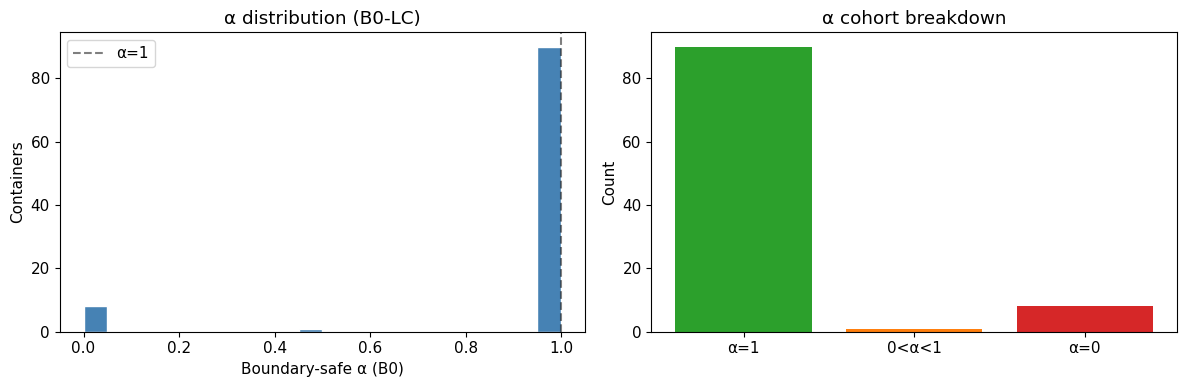

α=0 containers (8): ['c_10306', 'c_12060', 'c_13308', 'c_14106', 'c_15035', 'c_15446', 'c_15555', 'c_15794']


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(alpha_b0['alpha'], bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(1.0, color='k', ls='--', alpha=0.5, label='α=1')
axes[0].set_xlabel('Boundary-safe α (B0)'); axes[0].set_ylabel('Containers')
axes[0].set_title('α distribution (B0-LC)'); axes[0].legend()

alpha_zero = alpha_b0.loc[alpha_b0['alpha'] == 0, 'container_id'].tolist()
axes[1].bar(['α=1', '0<α<1', 'α=0'],
            [ (alpha_b0['alpha']==1).sum(), ((alpha_b0['alpha']>0)&(alpha_b0['alpha']<1)).sum(), (alpha_b0['alpha']==0).sum()],
            color=['#2ca02c', '#ff7f0e', '#d62728'])
axes[1].set_title('α cohort breakdown'); axes[1].set_ylabel('Count')
plt.tight_layout(); plt.show()
print('α=0 containers (8):', alpha_zero)


## 4 — Synthetic data explorer (sample container)


Sample container: c_10733


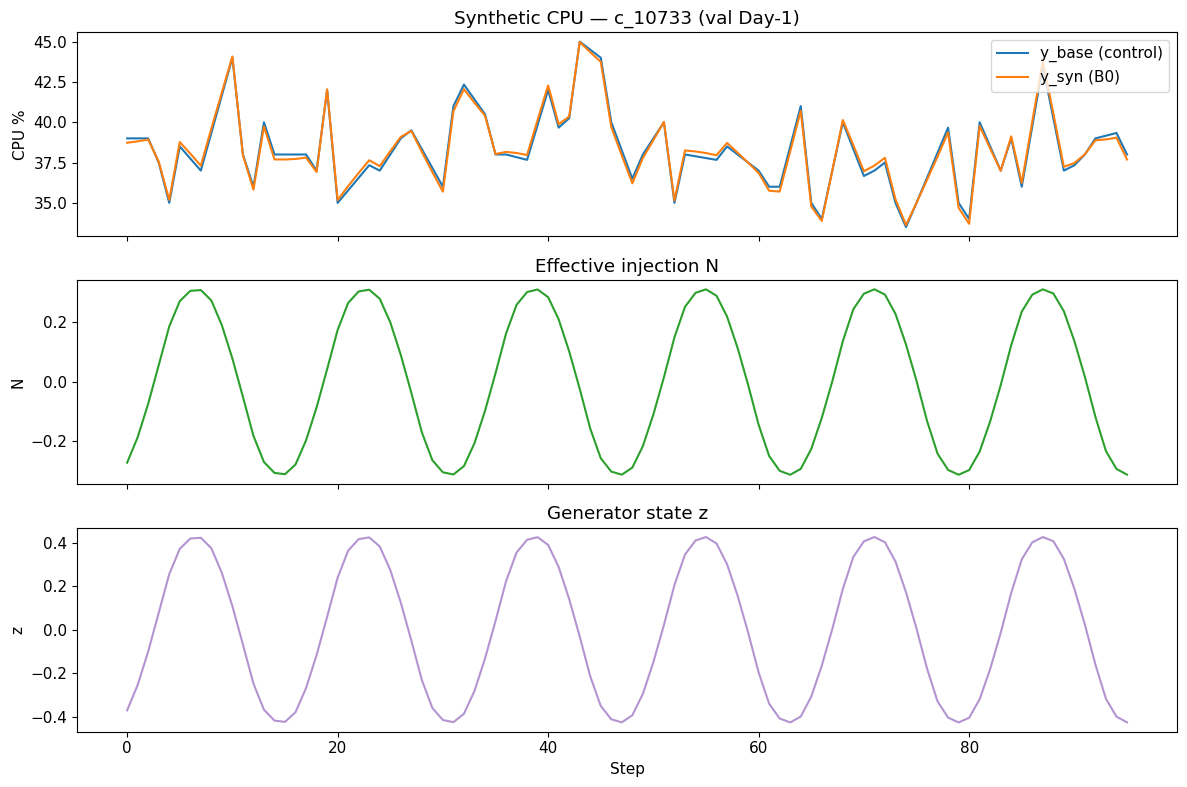

In [4]:
manifest = pd.read_parquet(DATA / 'ground_truth' / 'injection_manifest.parquet')
control_val = pd.read_parquet(DATA / 'control' / 'val_syn.parquet')
b0_val = pd.read_parquet(DATA / 'b0_lc' / 'val_syn.parquet')

# Representative: median α among active containers, or first α=1
sample_cid = alpha_b0.loc[alpha_b0['alpha']==1, 'container_id'].iloc[10]
print('Sample container:', sample_cid)

m = manifest[(manifest['container_id']==sample_cid) & (manifest['condition_id']=='b0_lc') & (manifest['split']=='val')].sort_values('time_stamp').head(96)
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(m['y_base'].values, label='y_base (control)', color='#1f77b4')
axes[0].plot(m['y_syn'].values, label='y_syn (B0)', color='#ff7f0e')
axes[0].set_ylabel('CPU %'); axes[0].set_title(f'Synthetic CPU — {sample_cid} (val Day-1)'); axes[0].legend()
axes[1].plot(m['N'].values, color='#2ca02c'); axes[1].set_ylabel('N'); axes[1].set_title('Effective injection N')
axes[2].plot(m['z'].values, color='#9467bd', alpha=0.7); axes[2].set_ylabel('z'); axes[2].set_xlabel('Step'); axes[2].set_title('Generator state z')
plt.tight_layout(); plt.show()


## 5 — Cross-condition metric matrix (Stage 2 + Condition A)

Heatmaps of cohort-mean residual-learning and CPU metrics across A / B0 / B1 / C0 / C1.


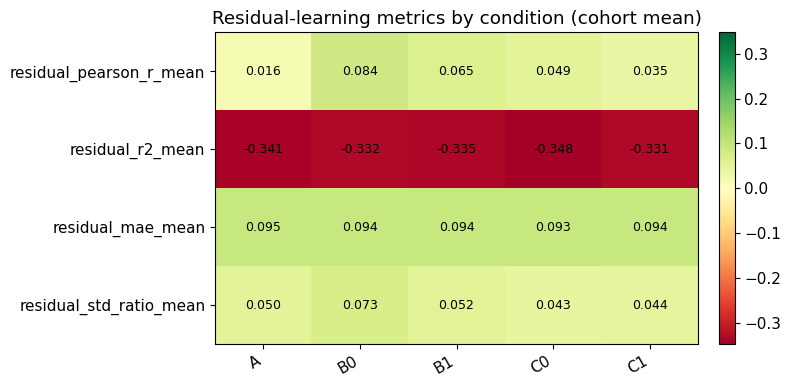

,residual_pearson_r_mean,residual_r2_mean,residual_mae_mean,residual_std_ratio_mean
A,0.0159,-0.3414,0.0948,0.0498
B0,0.0841,-0.3322,0.0936,0.0730
B1,0.0649,-0.3350,0.0936,0.0518
C0,0.0493,-0.3476,0.0935,0.0427
C1,0.0354,-0.3314,0.0936,0.0436


In [5]:
# Residual-learning matrix
res_cols = ['residual_pearson_r_mean', 'residual_r2_mean', 'residual_mae_mean', 'residual_std_ratio_mean']
res_mat = residual_summary.set_index('condition')[res_cols]
res_mat.index = ['A', 'B0', 'B1', 'C0', 'C1']

plot_heatmap(res_mat.T, 'Residual-learning metrics by condition (cohort mean)')
display(res_mat.round(4))


## 6 — CPU forecasting: Prophet vs Hybrid by condition


,prophet_mae,hybrid_mae,delta_mae
condition,,,
B0,1.7734,1.7670,-0.0064
B1,1.7865,1.7896,0.0031
C0,1.7789,1.7800,0.0011
C1,1.7605,1.7633,0.0027


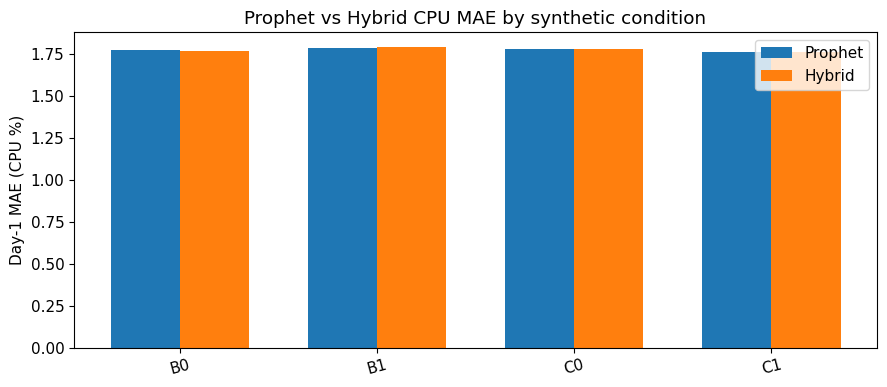

In [6]:
cpu_frames = []
labels = []
for label, (cid, path) in CONDITIONS.items():
    if label.startswith('A'):
        continue  # Stage 1 eval CSV
    cpu = pd.read_csv(path / 'evaluation' / 'cpu_metrics.csv')
    cpu['condition'] = label
    cpu_frames.append(cpu)
cpu_all = pd.concat(cpu_frames, ignore_index=True)

cpu_summary = cpu_all.groupby('condition').agg(
    prophet_mae=('prophet_day1_mae', 'mean'),
    hybrid_mae=('hybrid_day1_mae', 'mean'),
    delta_mae=('hybrid_minus_prophet_mae', 'mean'),
).round(4)
display(cpu_summary)

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(cpu_summary))
w = 0.35
ax.bar(x - w/2, cpu_summary['prophet_mae'], width=w, label='Prophet')
ax.bar(x + w/2, cpu_summary['hybrid_mae'], width=w, label='Hybrid')
ax.set_xticks(x, cpu_summary.index, rotation=15)
ax.set_ylabel('Day-1 MAE (CPU %)'); ax.set_title('Prophet vs Hybrid CPU MAE by synthetic condition')
ax.legend(); plt.tight_layout(); plt.show()


## 7 — Stage 1 Condition A (real-data reference)


=== Stage 1 CPU (Condition A) ===


,day1_mae,day1_rmse,day1_mape
0,1.744701,2.385636,111.614674
1,2.473811,3.204359,612.761568
2,0.003478,0.003701,4.606255
3,17.500639,22.613202,5909.505810


=== Stage 1 residual learning (extended) ===


,residual_pearson_r,residual_r2,residual_std_ratio
count,99.0000,99.0000,99.0000
mean,0.0159,-0.3414,0.0498
std,0.1954,0.9627,0.0492
min,-0.6029,-8.2598,0.0050
25%,-0.1070,-0.2666,0.0219
50%,0.0231,-0.0717,0.0354
75%,0.1555,-0.0092,0.0567
max,0.6181,0.0190,0.3313


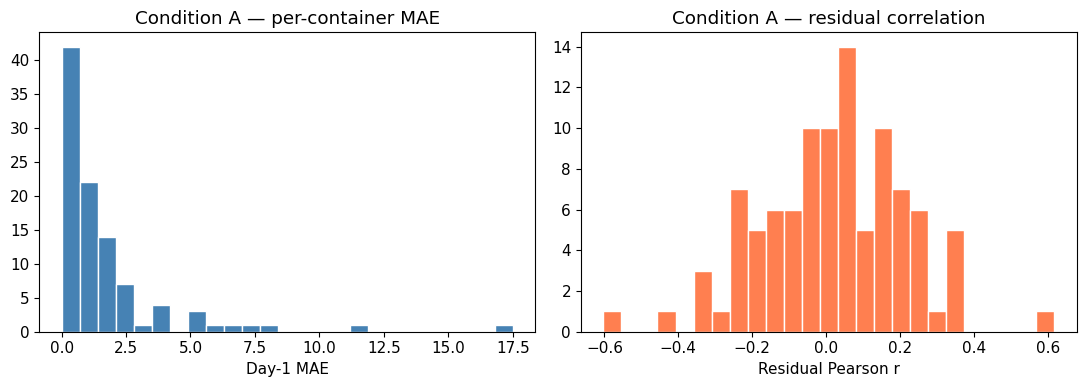

In [7]:
a_eval = pd.read_csv(STAGE1 / 'evaluation' / 'csrle_new_model_evaluation_df.csv')
a_ext = pd.read_csv(STAGE1 / 'evaluation' / 'csrle_new_model_extended_metrics.csv')
a_summary = pd.read_csv(STAGE1 / 'evaluation' / 'csrle_new_model_summary.csv')

print('=== Stage 1 CPU (Condition A) ===')
display(a_summary)
print('=== Stage 1 residual learning (extended) ===')
display(a_ext[['residual_pearson_r','residual_r2','residual_std_ratio']].describe().round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(a_eval['day1_mae'], bins=25, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Day-1 MAE'); axes[0].set_title('Condition A — per-container MAE')
axes[1].hist(a_ext['residual_pearson_r'], bins=25, color='coral', edgecolor='white')
axes[1].set_xlabel('Residual Pearson r'); axes[1].set_title('Condition A — residual correlation')
plt.tight_layout(); plt.show()


## 8 — Controlled comparisons: B0 vs C0, B1 vs C1


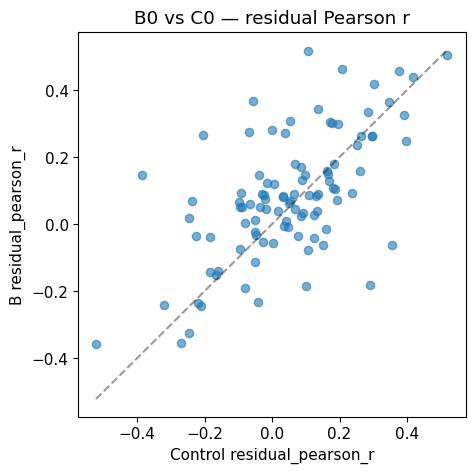

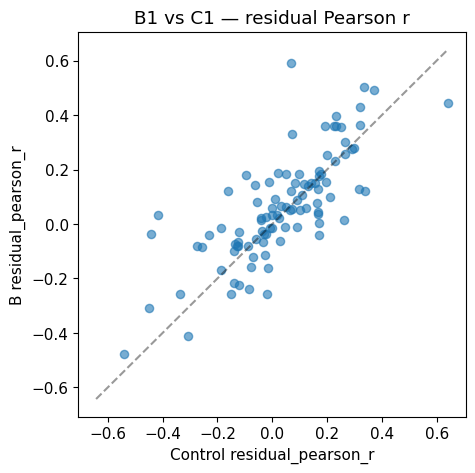

B0 vs C0 bootstrap (r): {'n_pairs': 99, 'mean_diff': 0.0348627800635338, 'median_diff': 0.01939831949560146, 'ci_low': 0.00359380284029669, 'ci_high': 0.06701637241814158, 'fraction_left_better': 0.5656565656565656}
B1 vs C1 bootstrap (r): {'n_pairs': 99, 'mean_diff': 0.029556101424056853, 'median_diff': 0.012450164839009011, 'ci_low': 0.0037088249794871198, 'ci_high': 0.05650241691136278, 'fraction_left_better': 0.5959595959595959}


In [8]:
b0_ext = pd.read_csv(STAGE2 / 'b0_lc' / 'evaluation' / 'extended_metrics.csv')
c0_ext = pd.read_csv(STAGE2 / 'c0_iid' / 'evaluation' / 'extended_metrics.csv')
b1_ext = pd.read_csv(STAGE2 / 'b1_snar' / 'evaluation' / 'extended_metrics.csv')
c1_ext = pd.read_csv(STAGE2 / 'c1_iid' / 'evaluation' / 'extended_metrics.csv')

def paired_plot(left, right, metric, title):
    m = left[['container_id', metric]].merge(right[['container_id', metric]], on='container_id', suffixes=('_b', '_c'))
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(m[f'{metric}_c'], m[f'{metric}_b'], alpha=0.6, s=35)
    lim = max(m[f'{metric}_c'].abs().max(), m[f'{metric}_b'].abs().max(), 0.05)
    ax.plot([-lim, lim], [-lim, lim], 'k--', alpha=0.4)
    ax.set_xlabel(f'Control {metric}'); ax.set_ylabel(f'B {metric}'); ax.set_title(title)
    plt.show()

paired_plot(b0_ext, c0_ext, 'residual_pearson_r', 'B0 vs C0 — residual Pearson r')
paired_plot(b1_ext, c1_ext, 'residual_pearson_r', 'B1 vs C1 — residual Pearson r')

print('B0 vs C0 bootstrap (r):', paired_boot.get('b0_lc_vs_c0_iid_full_residual_pearson_r'))
print('B1 vs C1 bootstrap (r):', paired_boot.get('b1_snar_vs_c1_iid_full_residual_pearson_r'))


## 9 — Baselines, horizons & training (B0)


,count,mean,std,min,25%,50%,75%,max
baseline,,,,,,,,
gru,99.0,0.0936,0.0654,0.0093,0.0501,0.0744,0.1276,0.3020
persistence,99.0,0.1084,0.0748,0.0032,0.0489,0.0987,0.1428,0.3441
ridge,99.0,0.0931,0.0662,0.0102,0.0483,0.0730,0.1248,0.3147
zero,99.0,0.0938,0.0650,0.0090,0.0509,0.0749,0.1266,0.3020


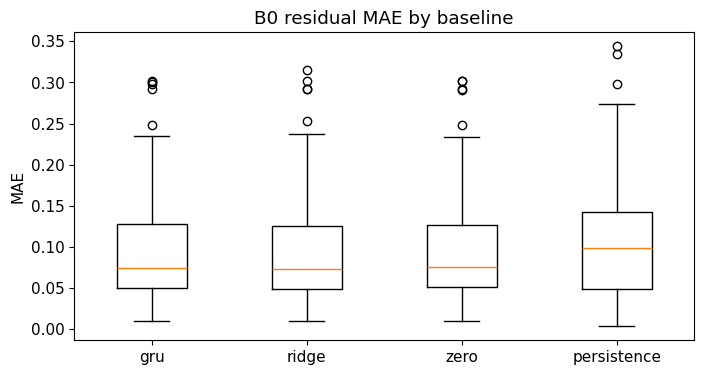

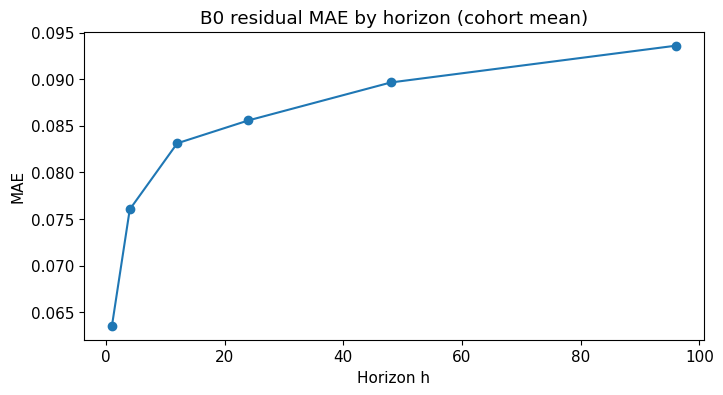

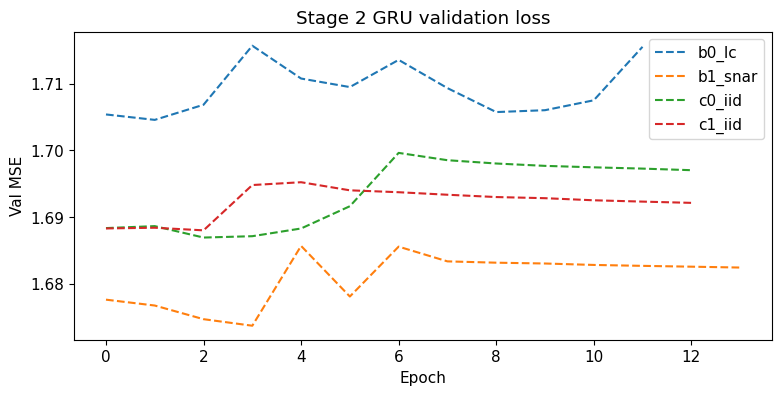

In [9]:
b0_base = pd.read_csv(STAGE2 / 'b0_lc' / 'evaluation' / 'baseline_comparison.csv')
display(b0_base.groupby('baseline')['residual_mae'].describe().round(4))

fig, ax = plt.subplots(figsize=(8, 4))
order = ['gru', 'ridge', 'zero', 'persistence']
data = [b0_base.loc[b0_base.baseline == b, 'residual_mae'].dropna().values for b in order]
ax.boxplot(data, tick_labels=order)
ax.set_title('B0 residual MAE by baseline'); ax.set_ylabel('MAE'); plt.show()

# Horizon cohort
hz = pd.read_csv(STAGE2 / 'b0_lc' / 'evaluation' / 'horizon_cohort_summary.csv')
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hz['horizon'], hz['mae'], marker='o')
ax.set_xlabel('Horizon h'); ax.set_ylabel('MAE'); ax.set_title('B0 residual MAE by horizon (cohort mean)'); plt.show()

# Training curves — all Stage 2 conditions
fig, ax = plt.subplots(figsize=(9, 4))
for cond in STAGE2_SYN:
    hist = pd.read_csv(STAGE2 / cond / 'training' / 'training_history.csv')
    ax.plot(hist['val_loss'], label=cond, ls='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val MSE'); ax.set_title('Stage 2 GRU validation loss'); ax.legend(); plt.show()


## 10 — Optional demo: single-container B0 Hybrid inference

Uses frozen Stage 2 B0 model. **Read-only** — does not retrain. Skip if slow.
Set `RUN_DEMO_INFERENCE = False` to disable.


In [10]:
RUN_DEMO_INFERENCE = False  # set True for Prophet+GRU demo plots

if RUN_DEMO_INFERENCE:
    sys.path.insert(0, str(REPO_ROOT))
    from utils.hybrid_artifacts import load_hybrid_artifacts
    from utils.csrle.stage2_training import build_condition_scalers, load_condition_frames
    from utils.hybrid_inference import run_hybrid_inference

    train_df, val_df = load_condition_frames(CSRLE_EXP, 'b0_lc')
    model, res_mean, res_std, iw = load_hybrid_artifacts(
        STAGE2 / 'b0_lc' / 'models' / 'hybrid_gru.keras',
        STAGE2 / 'b0_lc' / 'models' / 'residual_stats.pkl',
    )
    scalers = build_condition_scalers(train_df)
    demo_cid = sample_cid
    result = run_hybrid_inference(demo_cid, train_df, val_df, model, scalers, res_mean, res_std)

    steps = np.arange(1, len(result.actual_day1_real)+1)
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    axes[0].plot(steps, result.actual_day1_real, label='Actual', lw=1.5)
    axes[0].plot(steps, result.prophet_day1_real, label='Prophet', lw=1.5)
    axes[0].plot(steps, result.day1_final_real, label='Hybrid', lw=1.5)
    axes[0].set_ylabel('CPU %'); axes[0].set_title(f'B0 Hybrid demo — {demo_cid}'); axes[0].legend()
    actual_res = result.actual_day1_scaled - result.day1_prophet
    axes[1].plot(steps, actual_res, label='Actual residual')
    axes[1].plot(steps, result.day1_residual, label='GRU pred residual')
    axes[1].set_xlabel('Step'); axes[1].set_ylabel('Scaled residual'); axes[1].legend()
    plt.tight_layout(); plt.show()
else:
    print('Demo inference skipped. Set RUN_DEMO_INFERENCE=True to enable.')


Demo inference skipped. Set RUN_DEMO_INFERENCE=True to enable.


## 11 — Prophet retention (pre-GRU, frozen CSV)

Visualize ρ(N,I), variance separation VS, and retention metrics from pre-GRU validation.


B0 retention columns: ['rho_n_delta_p', 'rho_n_i', 'vs', 'vr', 'var_n', 'var_delta_p', 'var_i', 'identity_max_abs_err', 'mean_abs_n', 'mean_abs_i', 'container_id'] ...


,rho_n_i,vs,vr
count,91.0000,91.0000,91.0000
mean,0.9991,0.0019,1.0003
std,0.0019,0.0039,0.0053
min,0.9821,0.0004,0.9876
25%,0.9992,0.0010,0.9984
50%,0.9994,0.0013,1.0004
75%,0.9995,0.0016,1.0016
max,0.9998,0.0360,1.0320


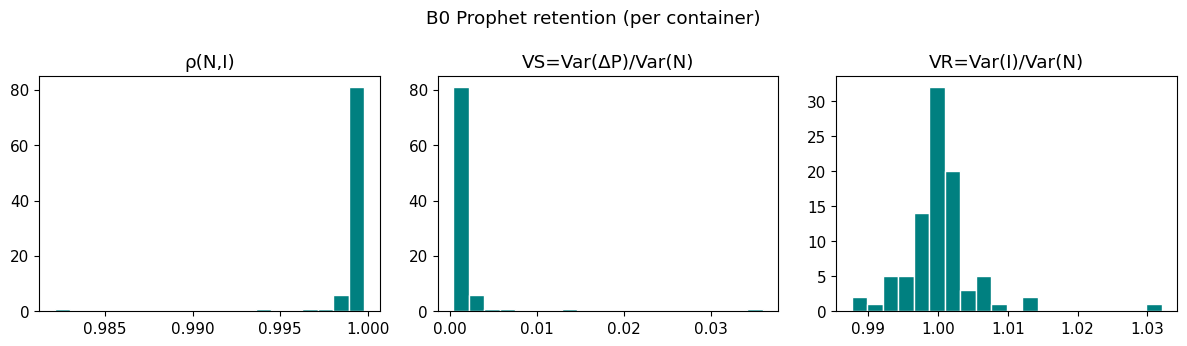

In [11]:
ret_b0 = pd.read_csv(PREGRU / 'prophet_retention_b0.csv')
print('B0 retention columns:', list(ret_b0.columns)[:12], '...')
display(ret_b0[['container_id', 'rho_n_i', 'vs', 'vr']].describe().round(4))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, col, title in zip(axes, ['rho_n_i', 'vs', 'vr'], ['ρ(N,I)', 'VS=Var(ΔP)/Var(N)', 'VR=Var(I)/Var(N)']):
    ax.hist(ret_b0[col].dropna(), bins=20, color='teal', edgecolor='white')
    ax.set_title(title)
plt.suptitle('B0 Prophet retention (per container)'); plt.tight_layout(); plt.show()


## 12 — Frozen Stage 2 plots (from experiment run)

Precomputed PNGs from `stage2_synthetic_gru/plots/` — same style as hybrid exploratory figures.


horizon_mae_by_condition.png


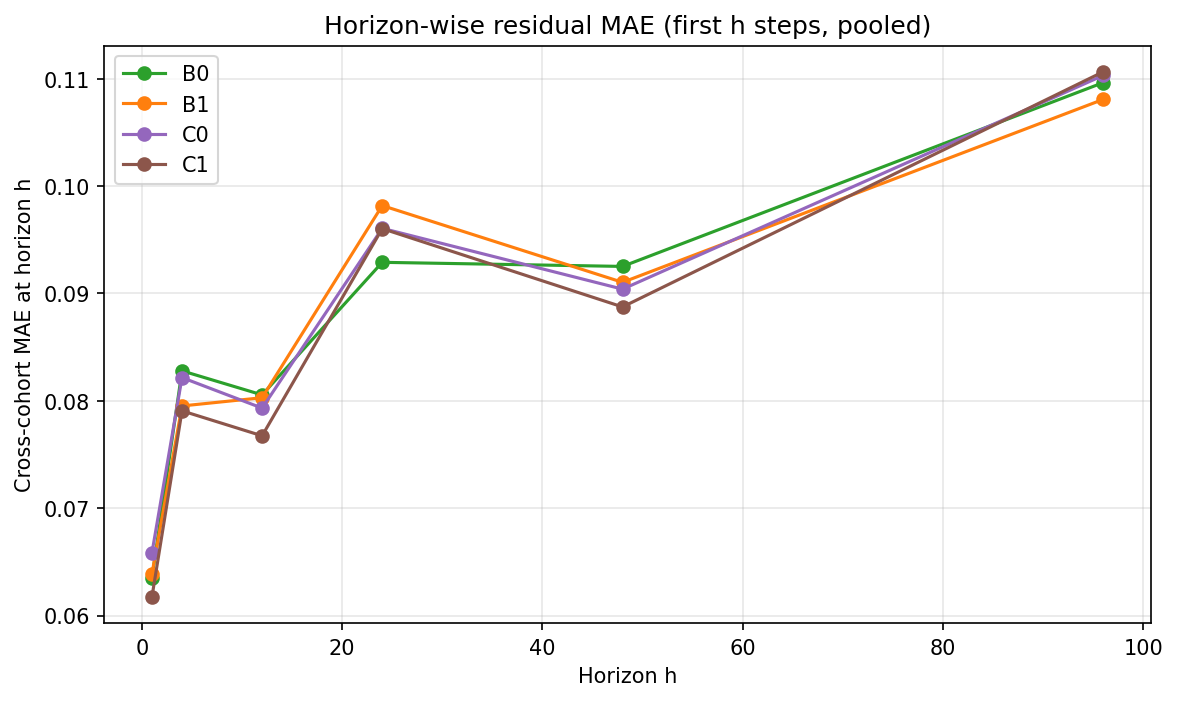

paired_b0_lc_vs_c0_iid_pearson_r.png


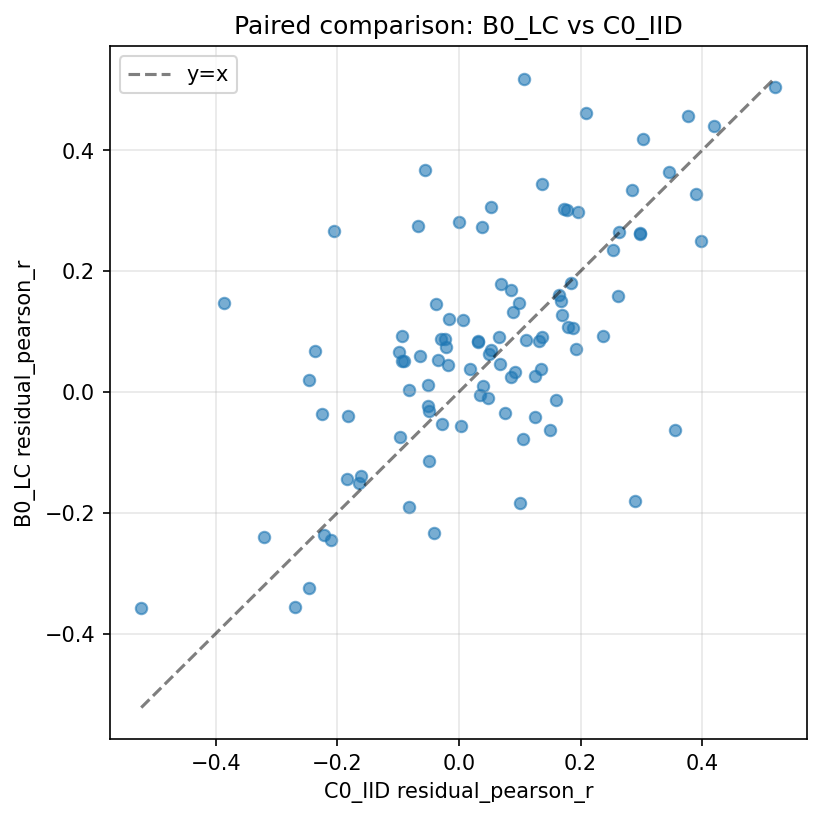

paired_b1_snar_vs_c1_iid_pearson_r.png


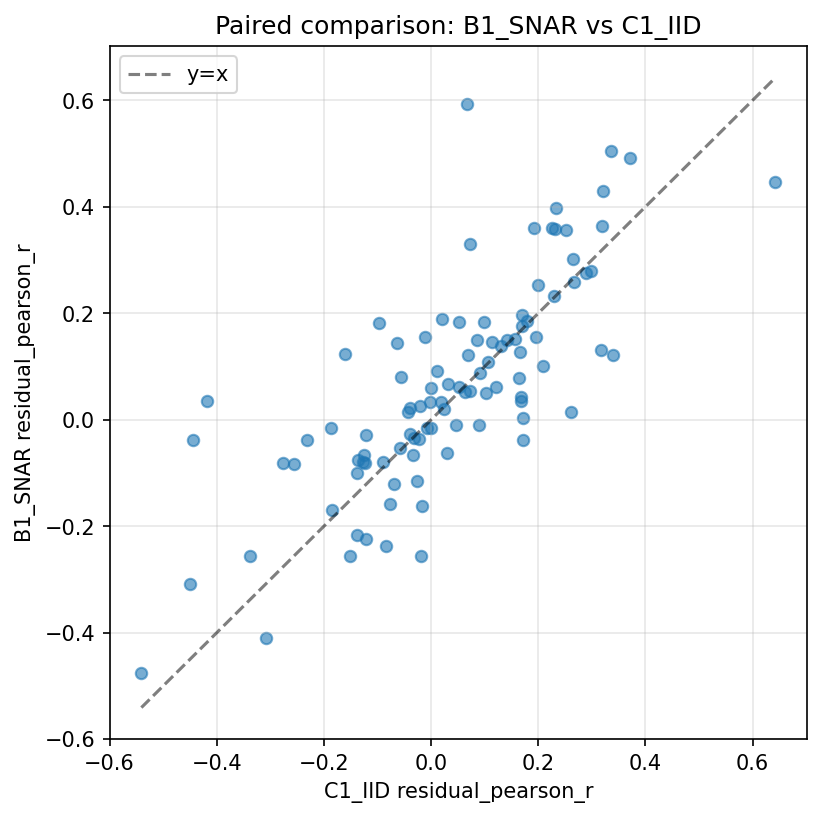

residual_pearson_r_distribution.png


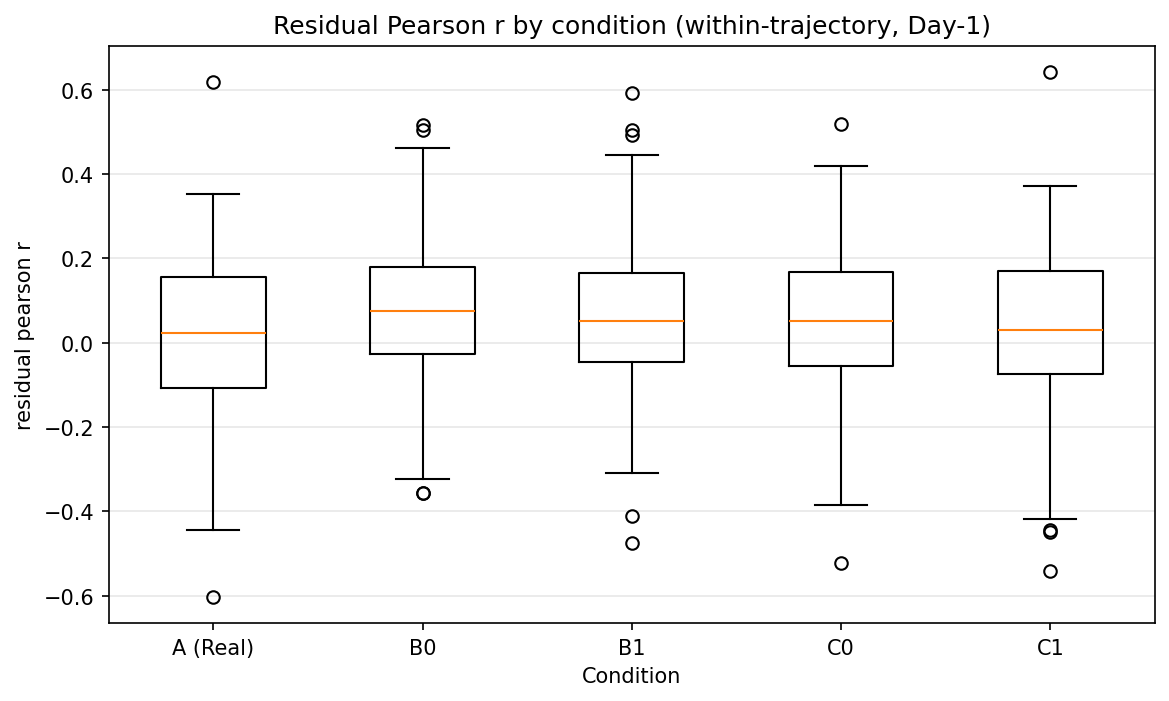

residual_r2_distribution.png


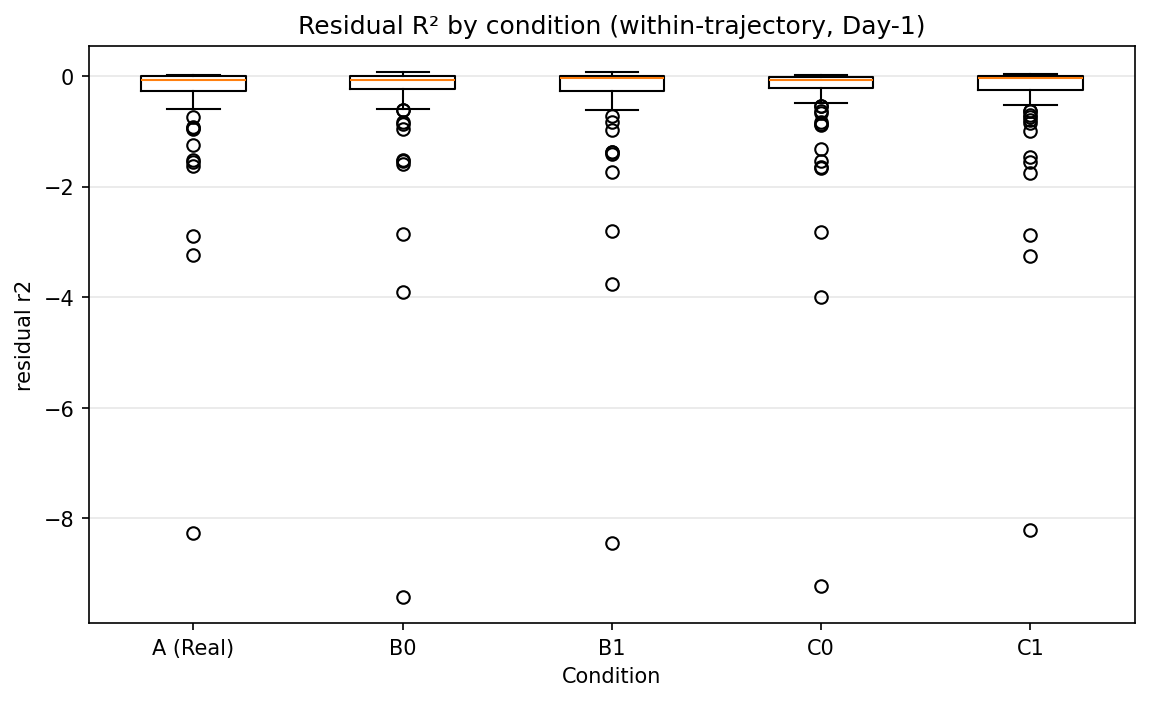

residual_std_ratio_distribution.png


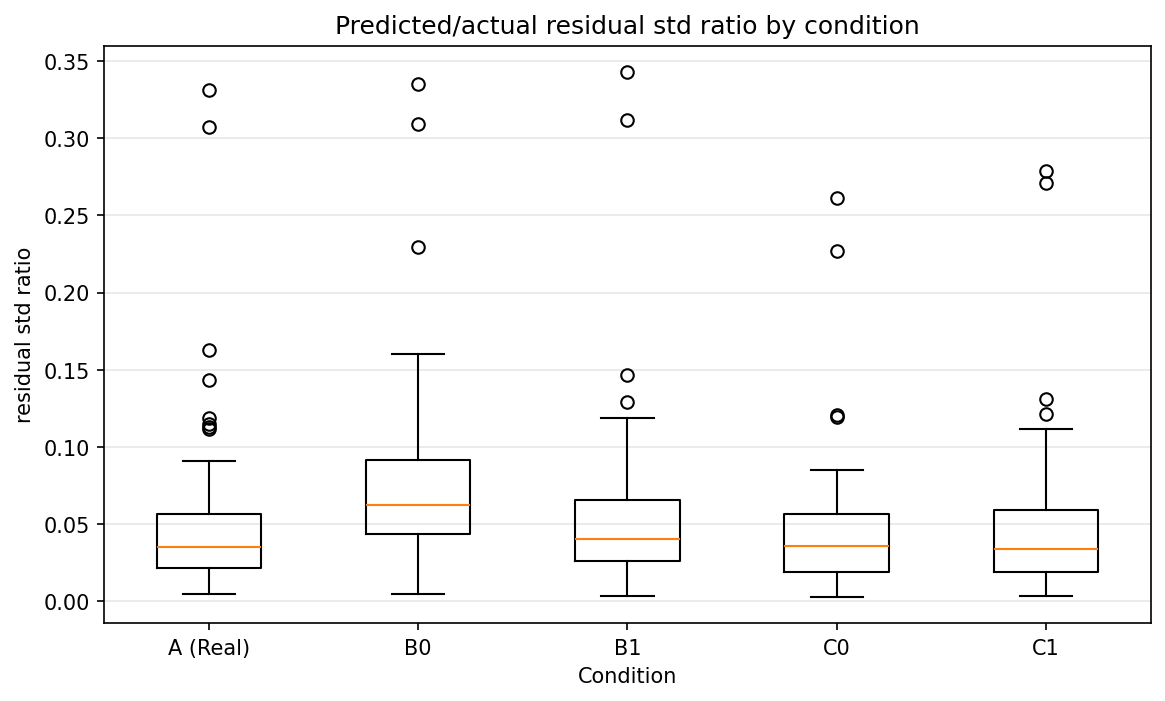

training_loss_comparison.png


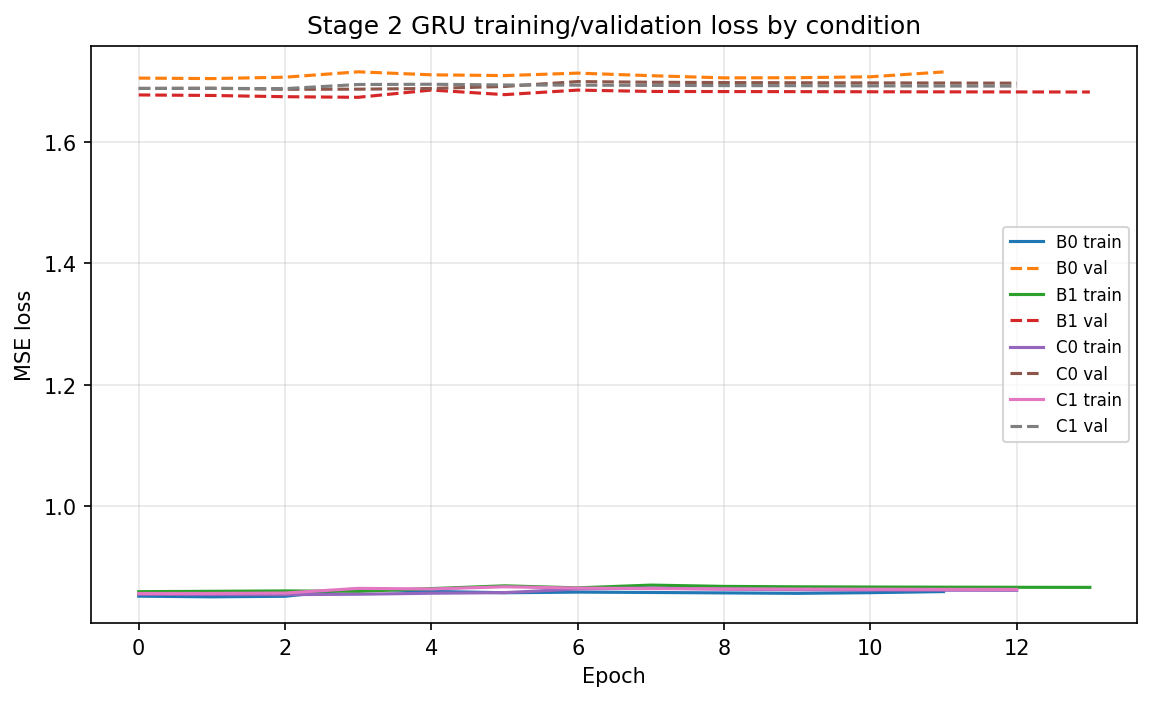

In [12]:
from IPython.display import Image, display

PLOT_DIR = STAGE2 / 'plots'
for name in sorted(PLOT_DIR.glob('*.png')):
    print(name.name)
    display(Image(filename=str(name), width=700))


## 13 — Summary dashboard

Quick reference tables loaded from frozen artifacts.


In [13]:
print('='*60)
print('CSRLE SUMMARY DASHBOARD')
print('='*60)
print('Residual learning (cohort mean r):')
print(residual_summary[['condition','residual_pearson_r_mean','residual_std_ratio_mean']].to_string(index=False))
print()
print('Stage 2 CPU delta (Hybrid - Prophet MAE):')
print(cpu_summary['delta_mae'].to_string())
print()
print('Pre-GRU: all generator gates passed:', pre_gru['generator_pass'])
print('Stage 1 reproduction gate:', json.loads((STAGE1/'verification'/'reproduction_gate_result.json').read_text())['pass'])
print('='*60)


CSRLE SUMMARY DASHBOARD
Residual learning (cohort mean r):
condition  residual_pearson_r_mean  residual_std_ratio_mean
  control                 0.015909                 0.049774
    b0_lc                 0.084134                 0.073003
  b1_snar                 0.064921                 0.051805
   c0_iid                 0.049271                 0.042743
   c1_iid                 0.035365                 0.043615

Stage 2 CPU delta (Hybrid - Prophet MAE):
condition
B0   -0.0064
B1    0.0031
C0    0.0011
C1    0.0027

Pre-GRU: all generator gates passed: {'b0_lc': True, 'b1_snar': True, 'c0_iid': True, 'c1_iid': True}
Stage 1 reproduction gate: True
